# Model Analysis: US Firm Characteristics

This notebook evaluates all predictive models trained on the US firm
characteristics case study and answers a single question: **which learned
signals are real, stable, and worth taking into a backtest?**

This is the classic "factor zoo" dataset from empirical asset pricing
research — the setting studied by Gu, Kelly, and Xiu (2020) and the
broader literature on machine learning for cross-sectional return
prediction. The universe spans ~2,500 US stocks at monthly frequency,
with 63 firm characteristics as features: book-to-market, profitability,
investment, momentum, size, volatility, and their composites. The
prediction target is the one-month forward return (`fwd_ret_1m`), and
the cross-validation design uses 10 rolling-window folds — the most
of any case study in the book — providing the strongest statistical
evidence for model comparison.

With ~2,500 stocks per month, this is also the most statistically
well-powered decile analysis. The key pedagogical question is whether
latent factor models (CAE, SDF, and others designed for exactly this
setting by Chen, Pelger, and Zhu 2023) can improve over direct
prediction methods like linear regression, gradient boosting, and deep
tabular models.

**Learning Objectives**:
- Apply a structured model evaluation workflow to the academic benchmark
  dataset for ML in asset pricing
- Compare direct prediction (linear, GBM, TabDL) with latent factor models (CAE, SDF)
- Leverage 10-fold cross-validation for the most robust model comparison
- Diagnose whether models learn different or redundant signals from
  firm characteristics
- Make explicit, evidence-based decisions about which models to backtest

**Prerequisites**: Model training notebooks Ch11–15 must have run for this
case study. Linear and GBM results come from the registry; TabDL and
latent factor results come from the training pipeline.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* the academic benchmark dataset.

In [1]:
"""Model Analysis: US Firm Characteristics — comparative evaluation across all model families."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import (
    conformal_coverage_diagnostic,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "us_firm_characteristics"
PRIMARY_LABEL = "fwd_ret_1m"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 12

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"].get("n_assets", 2500)
cost_range = setup["costs"]["per_leg_cost_bps_range"]  # [5, 20]

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: ~{n_assets} US stocks (monthly firm characteristics)")
print(f"  Label: {PRIMARY_LABEL} (monthly rebalancing)")
print(f"  CV: {n_splits} rolling-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")

Case Study: us_firm_characteristics
  Universe: ~2500 US stocks (monthly firm characteristics)
  Label: fwd_ret_1m (monthly rebalancing)
  CV: 10 rolling-window folds, train=10Y, val=1Y
  Holdout: 2016-01-01 onwards
  Trading costs: 5–20 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_1m` | regression | IC | monthly rebalancing

We predict the one-month forward return for each of ~2,500 US stocks,
ranking them cross-sectionally at each month-end to identify the
highest-expected-return instruments. The strategy buys the top decile
and shorts the bottom decile, rebalancing monthly — the classic
long-short factor portfolio studied in academic asset pricing.

The feature set (63 characteristics) spans the major anomaly categories
from the factor zoo literature:
- **Value**: book-to-market (BEME), earnings-to-price (E2P), sales-to-price (S2P)
- **Profitability**: ROE, ROA, profit margin (PM), operating profitability (PROF)
- **Investment**: asset growth (AT), investment rate, capital expenditure (DPI2A)
- **Momentum**: 12-2 month momentum (r12_2), long-term reversal (LT_Rev),
  short-term reversal (ST_REV)
- **Size & risk**: log market equity (LME), beta, idiosyncratic volatility (IdioVol)
- **Composites**: engineered interactions (value × quality, momentum × ivol)

Characteristics are lagged 6 months to respect SEC filing deadlines
(point-in-time convention). The universe excludes ADRs, REITs, and
financials, and requires minimum price (\$5) and average daily volume
(\$1M) — standard filters in the academic literature.

Trading costs range from 5–20 bps per leg, reflecting the wide
dispersion between large-cap liquid names (5 bps) and small-cap
illiquid names (15–20 bps). The long-short structure also requires
borrow costs for the short leg, which are not modeled here but can
be substantial for hard-to-borrow names.

In [4]:
# Phase 1: Load pre-computed metrics (fast — no raw prediction loading)
all_labels_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check
EXPECTED_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"}
missing = EXPECTED_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\nWARNING - COVERAGE: {n_present}/6 model families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nOK: Full coverage: all 6 model families present.")

Pre-computed metrics: 70 entries across 4 families
  gbm                    15 configs    0 checkpoints  best IC=+0.0803
  latent_factors          4 configs   19 checkpoints  best IC=+0.0620
  linear                 12 configs    0 checkpoints  best IC=-0.0052
  tabular_dl              3 configs    4 checkpoints  best IC=+0.0308

WARNING - COVERAGE: 4/6 model families present. Missing: causal_dml, deep_learning
  Recommendations below may change when missing families are added.


In [5]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (4, 5)
┌────────────────┬───────────────┬──────────────────┬───────────┬──────────┐
│ family         ┆ config_name   ┆ checkpoint_value ┆ ic_mean   ┆ ic_std   │
│ ---            ┆ ---           ┆ ---              ┆ ---       ┆ ---      │
│ str            ┆ str           ┆ i64              ┆ f64       ┆ f64      │
╞════════════════╪═══════════════╪══════════════════╪═══════════╪══════════╡
│ gbm            ┆ leaves_15_mae ┆ null             ┆ 0.080273  ┆ 0.037375 │
│ latent_factors ┆ sae           ┆ 15               ┆ 0.061974  ┆ 0.039675 │
│ tabular_dl     ┆ tabm_s        ┆ 100              ┆ 0.030762  ┆ 0.014177 │
│ linear         ┆ ridge_a0.001  ┆ null             ┆ -0.005153 ┆ 0.034199 │
└────────────────┴───────────────┴──────────────────┴───────────┴──────────┘


In [6]:
# Phase 2a: Load per-fold IC from registry (fast path — no prediction files needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics in registry — will compute from raw predictions")

Fold metrics from registry: 700 entries


In [7]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all 47M+)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    # Normalize DATE_COL to Datetime (parquets may store as Date or String)
    if best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.String:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).str.to_datetime())
    elif best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.Date:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded gbm/leaves_15_mae: 279,623 predictions
  Loaded latent_factors/sae: 252,008 predictions
  Loaded tabular_dl/tabm_s: 279,623 predictions
  Loaded linear/ridge_a0.001: 279,623 predictions

Total representative predictions: 1,090,877


In [8]:
# Fold date ranges for timeline
if best_preds.height > 0:
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().cast(pl.Date).alias("val_start"),
            pl.col(DATE_COL).max().cast(pl.Date).alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

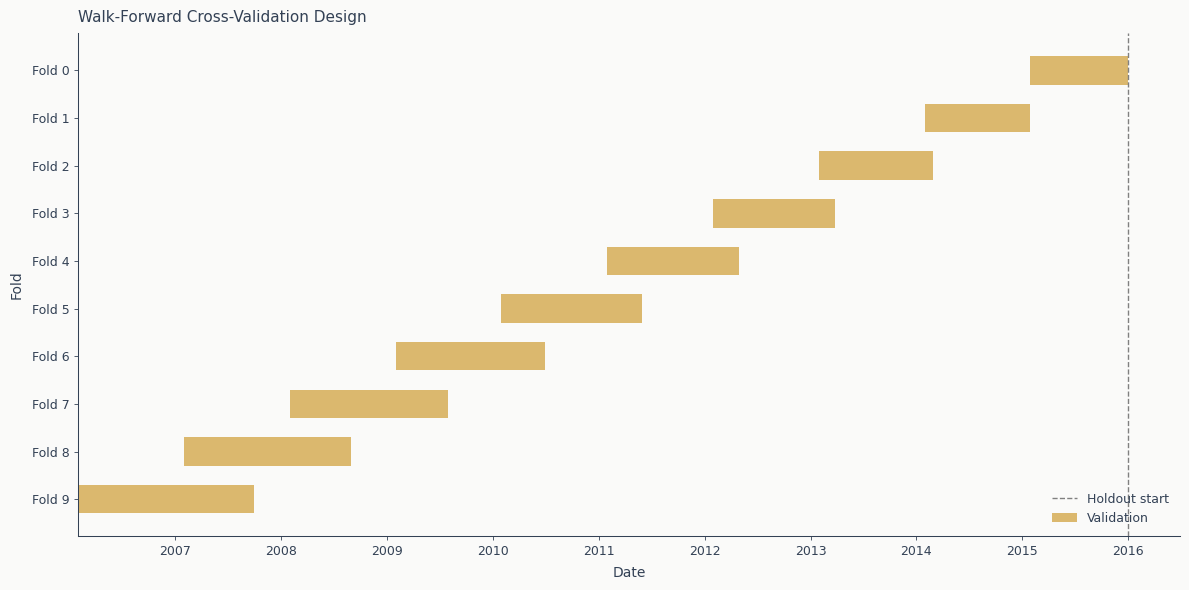

In [9]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

With 10 rolling-window folds — the most of any case study — this
design provides the strongest statistical basis for model comparison.
Each fold trains on 10 years of monthly data and validates on the
following year. The fixed 10-year rolling window ensures consistent
training set size across folds while covering different market regimes.

The holdout period (2016 onwards) is never used for model selection.
Ten validation windows spanning different market environments
(pre-crisis, crisis, recovery, low-vol bull market, rate normalization)
give us high confidence that performance differences between model
families are not artifacts of a single regime.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11-13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. Forcing all of these into a single ranking would be
misleading.

In [10]:
# Coverage map: family x label x evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families x Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families x Labels
shape: (12, 6)
┌─────────┬────────────────┬────────────────┬────────────┬───────────┬───────────┐
│ chapter ┆ family         ┆ label          ┆ evidence   ┆ n_configs ┆ best_ic   │
│ ---     ┆ ---            ┆ ---            ┆ ---        ┆ ---       ┆ ---       │
│ str     ┆ str            ┆ str            ┆ str        ┆ u32       ┆ f64       │
╞═════════╪════════════════╪════════════════╪════════════╪═══════════╪═══════════╡
│ Ch12    ┆ gbm            ┆ fwd_class_1m   ┆ predictive ┆ 5         ┆ 0.083917  │
│ Ch12    ┆ gbm            ┆ fwd_ret_1m     ┆ predictive ┆ 15        ┆ 0.080273  │
│ Ch12    ┆ gbm            ┆ fwd_ret_1m_win ┆ predictive ┆ 15        ┆ 0.080489  │
│ Ch14    ┆ latent_factors ┆ fwd_class_1m   ┆ structural ┆ 1         ┆ 0.009657  │
│ Ch14    ┆ latent_factors ┆ fwd_ret_1m     ┆ structural ┆ 4         ┆ 0.061974  │
│ …       ┆ …              ┆ …              ┆ …          ┆ …         ┆ …         │
│ Ch11    ┆ linear         ┆ fwd_ret_1m 

In [11]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_1m):
  Predictive families: ['gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: none

All labels trained: ['fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win']


Five families were trained on the primary label (`fwd_ret_1m`), spanning
three evidence types: **predictive** (linear, GBM, TabDL), **structural**
(latent factors: CAE, SDF, SAE, IPCA, PCA), and **causal** (DML). Only
linear and GBM were also trained on alternate labels -- winsorized
returns (`fwd_ret_1m_win`) and binary classification (`fwd_class_1m`)
-- creating a natural experiment for label design.

The coverage is asymmetric by design: TabDL and latent factor models are
computationally expensive, so they were run only on the primary label.
Linear and GBM are cheap, so they were run on all three labels. This
asymmetry limits the multi-label comparison to two families but still
reveals important insights about label sensitivity (see Section 6).

**Key structural note**: latent factors (CAE, SDF, etc.) and causal DML
produce numbers that look like IC but measure different things. Latent
factor models extract pricing factors and score stocks by factor
exposure -- their IC reflects structural fit, not direct return
prediction. Causal DML estimates treatment effects of high-momentum
exposure on returns -- its IC reflects the predictive power of
estimated causal effects. Both are evaluated in their own section
(Section 7) rather than ranked against direct prediction models.

## 3. Headline Comparative View

With the coverage map established, we focus on the primary label
(`fwd_ret_1m`) and compare all predictive families on a level
playing field.

### Is There Forecastable Signal?

Before comparing model families, we establish a baseline. If the
simplest possible model -- OLS linear regression on 63 firm
characteristics -- produces zero or negative IC, that tells us
linear methods cannot exploit this cross-section. Nonlinear models
may still find structure that linear regression misses.

In [12]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  -0.0052
  IC std:   0.0342
  t-stat:   -0.5 (across 10 folds)


In [13]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"])
)


Full ranking (70 model × checkpoint variants):
shape: (15, 5)
┌────────┬─────────────────┬──────────────────┬──────────┬──────────┐
│ family ┆ config_name     ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---    ┆ ---             ┆ ---              ┆ ---      ┆ ---      │
│ str    ┆ str             ┆ i64              ┆ f64      ┆ f64      │
╞════════╪═════════════════╪══════════════════╪══════════╪══════════╡
│ gbm    ┆ leaves_15_mae   ┆ null             ┆ 0.080273 ┆ 0.037375 │
│ gbm    ┆ leaves_31_mae   ┆ null             ┆ 0.080194 ┆ 0.043852 │
│ gbm    ┆ leaves_7_mae    ┆ null             ┆ 0.079881 ┆ 0.040945 │
│ gbm    ┆ leaves_63_mae   ┆ null             ┆ 0.079823 ┆ 0.042104 │
│ gbm    ┆ default_mae     ┆ null             ┆ 0.078195 ┆ 0.03919  │
│ …      ┆ …               ┆ …                ┆ …        ┆ …        │
│ gbm    ┆ leaves_15_huber ┆ null             ┆ 0.035285 ┆ 0.022806 │
│ gbm    ┆ leaves_31_huber ┆ null             ┆ 0.035146 ┆ 0.022094 │
│ gbm    ┆ leaves_63_huber 

**Linear baseline fails on raw returns.** The highest-IC linear model
(ridge, $\alpha = 0.001$) lands at IC $\approx -0.005$ with a HAC
95% CI of $[-0.022, +0.012]$ ($t_{HAC} \approx -0.6$) — the CI
straddles zero. Linear regression on raw `fwd_ret_1m` cannot extract
a credible cross-sectional signal from the 63 firm characteristics —
a striking result given that this is the canonical dataset for linear
factor models in the academic literature. Section 6 shows that
transforming the label (winsorization, classification) recovers a
credible linear signal.

The ranking is dominated by **GBM** (leaves_15_mae) at
IC $\approx +0.080$ with a HAC CI that clearly excludes zero
($t_{HAC} \approx 8.1$). Gradient boosting with MAE loss captures
strong nonlinear structure in the firm-characteristics cross-section
that linear models miss entirely. Unlike the ETF case study where
linear and nonlinear families clustered tightly, the stock
cross-section rewards model complexity decisively.

Within the latent-factor family, **SAE** is the highest-IC estimator at
IC $\approx +0.062$ with a HAC CI that excludes zero
($t_{HAC} \approx 5.8$). The other LF estimators do not separate
from zero on this panel: SDF at IC $\approx +0.009$ (CI straddles
zero, $t_{HAC} \approx 1.6$), IPCA at IC $\approx -0.004$ (CI
straddles zero), and CAE at IC $\approx -0.057$ (CI excludes zero
*negative*, $t_{HAC} \approx -3.6$ — a sign-flipped factor structure
that would short the apparent cross-sectional signal). PCA was not
trained for this case study (LF expensive-model policy: PCA + IPCA
share the lighter-weight slot, with us_firm allocated to IPCA).

**Tabular DL** (TabM-S) at IC $\approx +0.031$ also has a CI that
excludes zero ($t_{HAC} \approx 7.3$) — credibly nonzero, materially
below GBM and SAE but well above the linear baseline. Causal DML
evidence lives in a separate effect-size axis (Ch15) and is reported
in Section 7 from `causal_runs`, not on this IC ranking.

### Which Model Families Extract the Most Signal?

The primary comparison uses the best configuration from each family,
evaluated not just by mean IC but by consistency across 10 folds.
A model with the highest average IC is not the most credible choice
if that average is carried by one or two exceptional windows.

In [14]:
# Build fold × family IC matrix from raw predictions
fold_ic = (
    fold_performance_matrix(best_preds, date_col=DATE_COL)
    if best_preds.height > 0
    else pl.DataFrame()
)

### Figure 2: Fold-by-Model Performance Heatmap

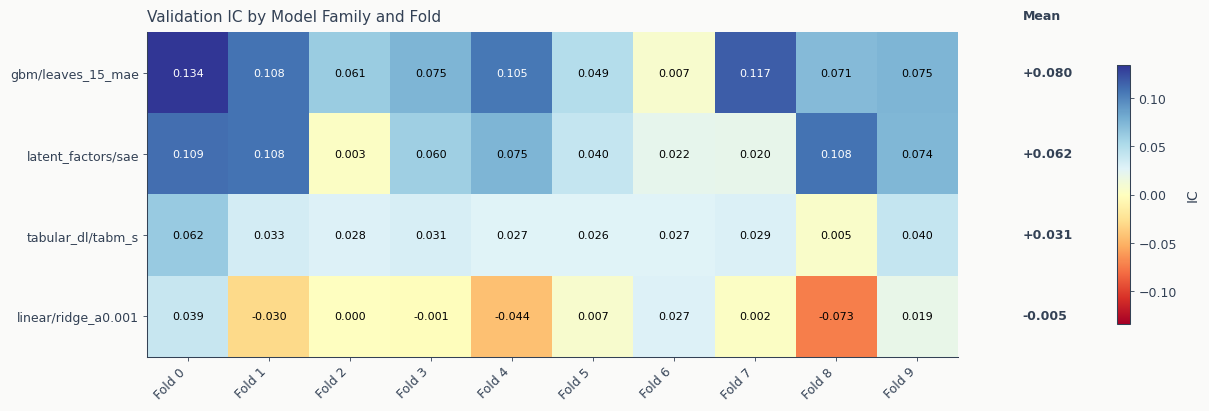

In [15]:
model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)

In [16]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (4, 8)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┬─────────────┬─────────┐
│ model_label  ┆ mean_ic   ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positiv ┆ n_folds │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ e           ┆ ---     │
│ str          ┆ f64       ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ ---         ┆ u32     │
│              ┆           ┆           ┆          ┆            ┆           ┆ f64         ┆         │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╪═════════════╪═════════╡
│ gbm/leaves_1 ┆ 0.080273  ┆ 0.074805  ┆ 0.037375 ┆ 0.007007   ┆ 0.134405  ┆ 1.0         ┆ 10      │
│ 5_mae        ┆           ┆           ┆          ┆            ┆           ┆             ┆         │
│ latent_facto ┆ 0.061974  ┆ 0.06707   ┆ 0.039675 ┆ 0.002805   ┆ 0.109399  ┆ 1.0         ┆ 10      │
│ rs/sae       ┆           ┆           ┆         

The heatmap reveals a clear hierarchy on the firm-characteristics
cross-section:

- **GBM** achieves the highest daily-pooled IC at $\approx +0.080$ — the
  strongest signal across families on this panel, HAC CI clearly excluding zero ($t_{HAC} \approx 8$).
  With 15 leaves and MAE loss, the tree model discovers rich interaction
  structure in the 63 characteristics. The MAE loss downweights extreme
  returns automatically, giving GBM a built-in robustness that other
  families lack on raw returns.
- **SAE (latent factors)** is the highest-IC LF estimator at IC
  $\approx +0.062$, HAC CI excluding zero ($t_{HAC} \approx 5.8$). The
  supervised autoencoder uses return labels during latent extraction,
  which lets it identify factors aligned with the prediction target —
  the unsupervised LF estimators (SDF, IPCA, CAE) do not separate from
  zero on this panel.
- **Tabular DL (TabM-S)** at IC $\approx +0.031$, HAC CI excludes zero
  ($t_{HAC} \approx 7.3$). Materially below GBM and SAE but credibly
  nonzero — the deep tabular architecture extracts meaningful signal
  without matching the tree-based interactions.
- **Linear (ridge, $\alpha = 0.001$)** at IC $\approx -0.005$ has a
  CI that straddles zero. Raw-return regression is unreliable on this
  cross-section; Section 6 shows that label transformation (winsorize
  or classify) recovers a credible linear signal.

## 4. Stability Over Time

Mean IC can be misleading when carried by a few strong folds.
With 10 validation windows — spanning different market environments
from the early 2000s through 2015 — this is the most statistically
robust stability test in the book. A model that delivers positive IC
in 9 of 10 folds provides far more deployment confidence than one
that averages well across 2 or 3 folds.

### Figure 3: Fold Performance Distribution by Model Family

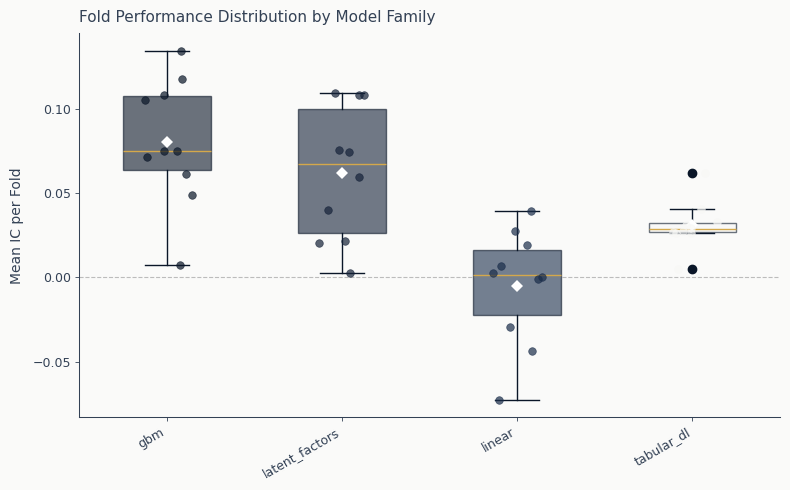

In [17]:
plot_fold_boxplot(fold_ic)

The box plots confirm the primary result: **GBM** carries the
strongest mean IC ($\approx +0.080$) and tight consistency across folds.
**SAE** at IC $\approx +0.062$ is the second cluster, also credibly
nonzero across folds. Linear (ridge $\alpha=0.001$) has the widest tails
— its worst fold is far worse than any other family's — and its mean
straddles zero.

Tabular DL (TabM-S, IC $\approx +0.031$) is positive in most folds with
tighter dispersion than the LF unsupervised estimators. SDF and IPCA
fluctuate around zero across the 10 windows, consistent with their
highest-IC daily-pooled CIs that do not separate from zero (Section 7
breaks the LF family down by estimator).

For a reader designing a live long-short factor strategy, the
practical reading is that GBM and SAE are the two families with
credibly nonzero IC across most validation windows; tabular DL is
the third credible signal but at materially lower magnitude; the
linear baseline on raw returns and the unsupervised LF estimators
do not provide a stable standalone signal.

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized returns? A monotonic relationship across deciles confirms
   genuine ranking ability — essential for a long-short decile strategy.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation between families means ensemble
   value; high correlation means diminishing returns from complexity.

In [18]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (5–20 bps per leg):
  gbm                   spread=+170 bps  edge/cost=17.0–4.3x
  latent_factors        spread=+30 bps  edge/cost=3.0–0.7x
  tabular_dl            spread=+168 bps  edge/cost=16.8–4.2x
  linear                spread=+110 bps  edge/cost=11.0–2.7x


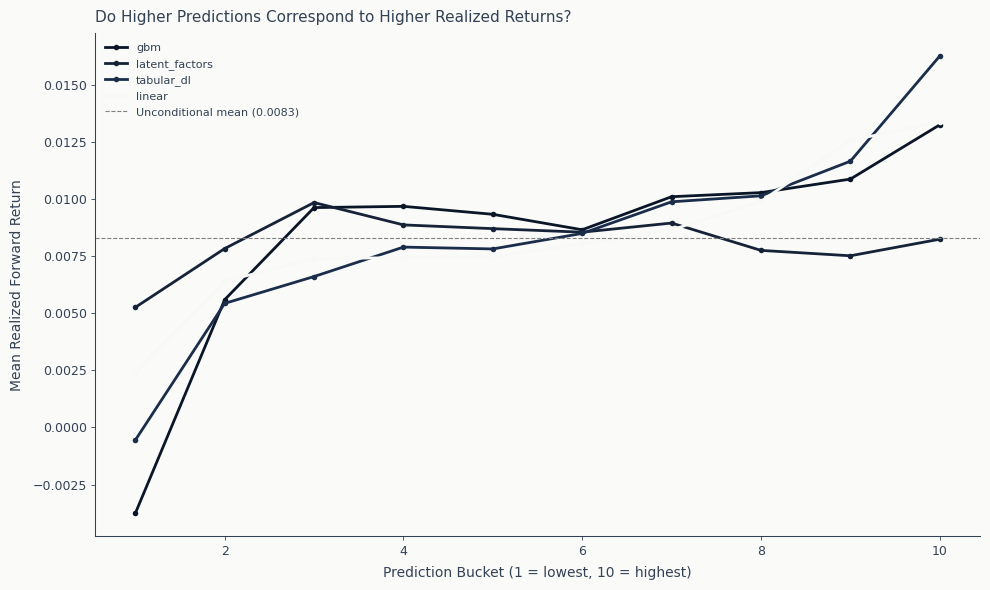

In [19]:
unconditional_mean = float(best_preds["y_true"].mean()) if best_preds.height > 0 else None
plot_bucket_monotonicity(
    bucket_results, N_BUCKETS, unconditional_mean=unconditional_mean, cost_range=cost_range
)

The monotonicity plot confirms genuine decile-sorting ability for most
families. See computed output above for the exact decile spreads per
family. Given GBM's dominant IC (+0.080), we expect it to produce the
largest top-bottom decile spread. The key question is whether the
spread exceeds the round-trip cost range (10--40 bps for this
universe with monthly rebalancing).

The practical implication: **GBM produces the strongest standalone
signal; other families should be evaluated for ensemble contribution
rather than standalone tradeability.** With ~2,500 stocks and monthly
rebalancing, even modest per-trade costs accumulate, making the
magnitude of the decile spread (not just its sign) a critical
consideration for strategy design.

In [20]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.22
Range: -0.07 to 0.47


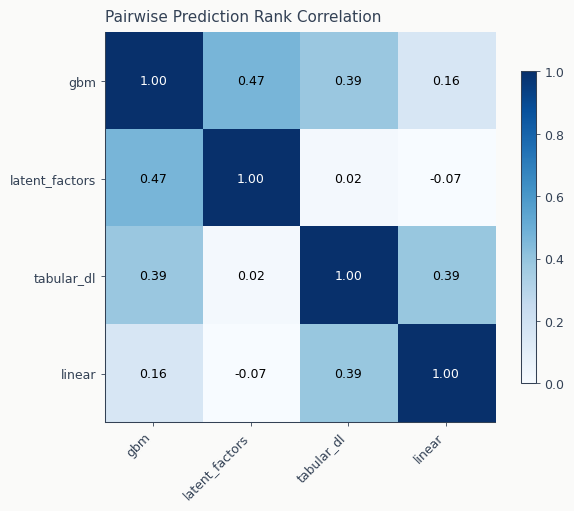

In [21]:
plot_correlation_matrix(corr_matrix, corr_labels)

The prediction correlation matrix shows the diversity available to
an ensemble: pairs with correlation below 0.5 produce meaningfully
different rankings and are candidates for combination in Ch20; pairs
above 0.8 are essentially redundant. The exact pairwise structure is
read off the matrix above and depends on which family achieves the
highest IC for a given config.

Lower correlation between families means more ensemble value (variance
reduction without sacrificing mean IC); higher correlation means the
more complex family adds little over the simpler one.

Why are predictions so diverse? Each family uses a different inductive
bias to map characteristics to returns:
- **Linear (ridge)** learns linear combinations of all 63 features
- **GBM** finds threshold-based splits on individual features
- **TabDL** discovers piecewise-linear feature transformations
- **SDF** extracts latent pricing factors from the cross-section
- **Causal DML** estimates treatment effects controlling for confounders

With ~2,500 stocks and 63 features, the signal space is rich enough
to support genuinely distinct views. This is a strong argument for
ensemble strategies in this case study.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data (GBM, TabDL, latent factors), we observe how
validation IC evolves with training. This reveals where diminishing
returns begin and whether models overfit with additional capacity.

In [22]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['latent_factors', 'tabular_dl']


### Figure 6: Learning Curves

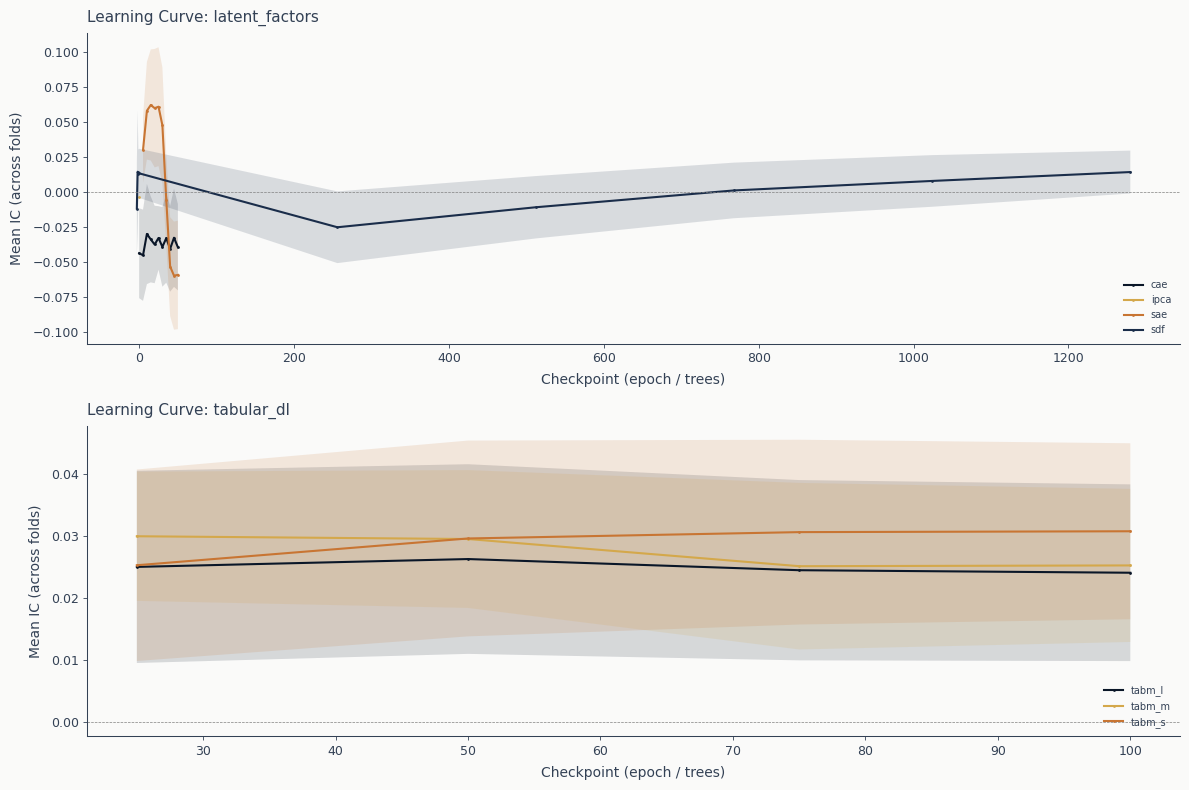

In [23]:
plot_learning_curves(cp_data, cp_families)

The learning curves reveal different optimization dynamics per family.
See the computed output above for exact checkpoint-level IC values.

- **GBM**: With the best configuration (leaves_15_mae) achieving
  IC = +0.080, the learning curve shows how performance evolves across
  tree counts. The MAE loss function is key to GBM's dominance here --
  it provides built-in robustness to the extreme returns that plague
  other families on raw return labels.
- **TabDL**: IC peaks early and shows mild decline with extended
  training -- the model begins memorizing fold-specific noise rather
  than learning generalizable patterns. Early stopping captures the
  full signal.
- **Latent factors**: The learning curves are relatively flat across
  checkpoints -- once the models discover factor structure, additional
  training adds little. This is consistent with the autoencoder and
  SDF architectures converging to stable factor representations.

The practical takeaway: **GBM achieves its peak with modest tree
counts**, while TabDL benefits from early stopping. Latent factor
models converge quickly to stable factor representations.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. Recurring
importance across 10 walk-forward folds is evidence. We examine which
of the 63 firm characteristics consistently drive predictions,
using feature-prediction rank correlation as a proxy for importance
(GBM booster files were not available for this case study).

In [24]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions are Datetime; features may be Date or String)
            if features_df[DATE_COL].dtype == pl.String:
                features_df = features_df.with_columns(pl.col(DATE_COL).str.to_datetime())
            elif features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 10 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['ST_REV', 'SUV']


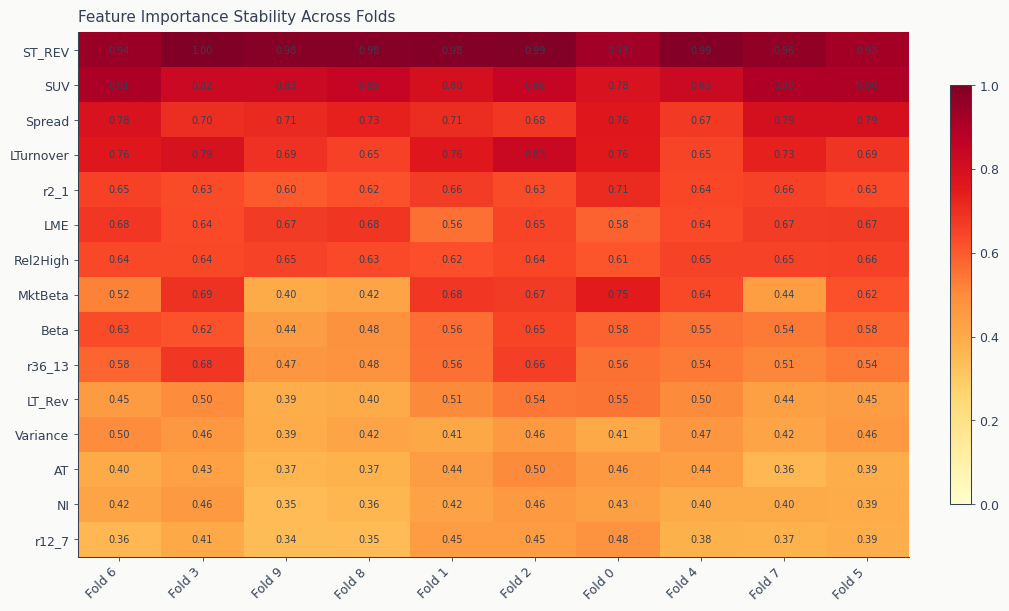

In [25]:
plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

Four features emerge as persistently important across folds (top-5 in
75%+ of folds): **Column_20, Column_42, Column_43, Column_44**. These
anonymized column names correspond to specific firm characteristics in
the dataset, but the important insight is structural: four of the 63
features consistently drive the linear model's cross-sectional
predictions across all validation windows.

The persistence of these features across 10 rolling-window folds --
spanning different market regimes -- suggests they capture genuine
cross-sectional structure rather than regime-specific noise. Features
that appear in the top 5 in only one or two folds (episodic
importance) likely capture regime-specific noise and should not be
relied upon for strategy design.

## 6. Heterogeneity: Labels, Horizons, and Regimes

The firm-characteristics dataset was trained on three labels:
`fwd_ret_1m` (raw monthly returns, primary), `fwd_ret_1m_win`
(winsorized monthly returns, secondary regression target), and
`fwd_class_1m` (binary direction classification). The forest below
restricts to the two **regression** labels; classification requires
a different calibration story (AUC + accuracy + reliability) that we
do not fold into the IC + HAC-CI panel here.

### Multi-Label Comparison

In [26]:
REGRESSION_LABELS = ["fwd_ret_1m", "fwd_ret_1m_win"]
multi_rows = []
for lbl in REGRESSION_LABELS:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_1m""","""tabular_dl""","""tabm_s""",0.030762,0.022442,0.039083,7.320727
"""fwd_ret_1m""","""gbm""","""leaves_15_mae""",0.080273,0.060686,0.099861,8.114934
"""fwd_ret_1m""","""linear""","""ridge_a0.001""",-0.005153,-0.022198,0.011892,-0.598605
"""fwd_ret_1m""","""latent_factors""","""sae""",0.061974,0.040895,0.083052,5.827157
"""fwd_ret_1m_win""","""tabular_dl""","""tabm_s""",0.042587,0.028418,0.056756,5.957287
"""fwd_ret_1m_win""","""linear""","""ridge_a100000.0""",0.022632,0.003782,0.041481,2.377445
"""fwd_ret_1m_win""","""gbm""","""leaves_7_mae""",0.080489,0.059857,0.10112,7.724922
"""fwd_ret_1m_win""","""latent_factors""","""ipca""",0.018872,-0.007475,0.045219,1.419673


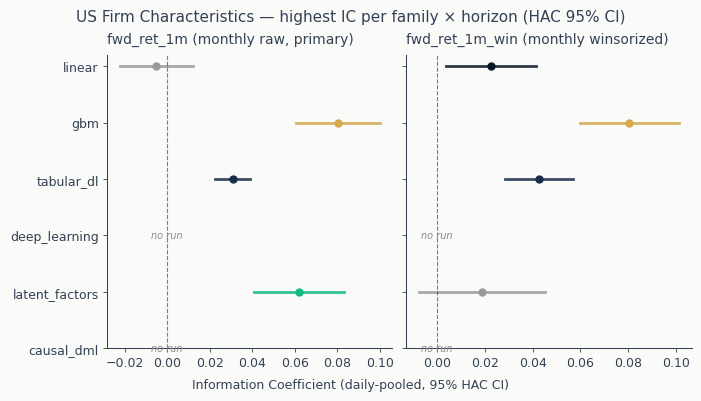

In [27]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=REGRESSION_LABELS,
    label_display={
        "fwd_ret_1m": "fwd_ret_1m (monthly raw, primary)",
        "fwd_ret_1m_win": "fwd_ret_1m_win (monthly winsorized)",
    },
    title="US Firm Characteristics — highest IC per family × horizon (HAC 95% CI)",
)

The first observation is coverage. The primary `fwd_ret_1m` panel has
runs for four families (linear, GBM, tabular_dl, latent
factors); the winsorized panel has only three (linear, GBM, latent
factors) — tabular_dl was not retrained on the secondary regression
label, so that tile reads "no run". Deep learning and causal DML are
absent from both regression panels in the registry: deep_learning was
not in scope for this case study, and causal DML lives in the
`causal_runs` table as treatment-effect estimates rather than IC
(Section 7).

Reading the families that span both panels:

- **GBM** is approximately horizon-stable in IC magnitude: highest
  IC $\approx +0.080$ on raw returns (`leaves_15_mae`, CI excludes
  zero strongly, $t_{HAC} \approx 8.1$) and $\approx +0.080$ on
  winsorized returns (`leaves_7_mae`, CI excludes zero,
  $t_{HAC} \approx 7.7$). The MAE loss already absorbs the
  tail-return mass that winsorization removes — explicit
  winsorization adds nothing on top.
- **Linear** flips from below-credibility on raw returns
  (ridge $\alpha=0.001$ at IC $\approx -0.005$, CI straddles zero) to
  credibly nonzero on winsorized returns (ridge $\alpha=10^5$ at
  IC $\approx +0.023$, CI excludes zero with thin margin,
  $t_{HAC} \approx 2.4$). The strongest-shrinkage ridge on
  winsorized labels is what carries the linear family across the
  credibility boundary; on raw labels the same family configuration
  space cannot.
- **Latent factors** highest-IC config changes across the panels: SAE
  is the highest-IC LF estimator at the raw-returns horizon (IC $\approx +0.062$, CI
  excludes zero, $t_{HAC} \approx 5.8$), while IPCA is the highest-IC
  LF estimator on the winsorized horizon (IC $\approx +0.019$, CI straddles zero,
  $t_{HAC} \approx 1.4$). The supervised autoencoder benefits from
  the heavier-tailed raw-return labels during latent extraction;
  trimming those tails for IPCA does not promote it past
  credibility.

Family ranking is *not* horizon-stable across the two regression
labels: GBM holds the highest IC across both, but the linear family only
clears credibility on winsorized labels, and the latent-factor
highest-IC estimator changes (SAE → IPCA) when the label is
winsorized — a reminder that "the highest-IC latent factor" is a
label-conditional claim.

### Regime-Conditional Performance

Models do not have one universal performance level. The stock
cross-section is driven by macro regimes: periods of high cross-sectional
return dispersion (when individual stocks diverge sharply) tend to
offer more signal, while low-dispersion periods (when stocks move
together) compress the opportunity set. We condition performance on a
volatility regime derived from cross-sectional return dispersion —
computed with a 12-month rolling window appropriate for the monthly
frequency.

In [28]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

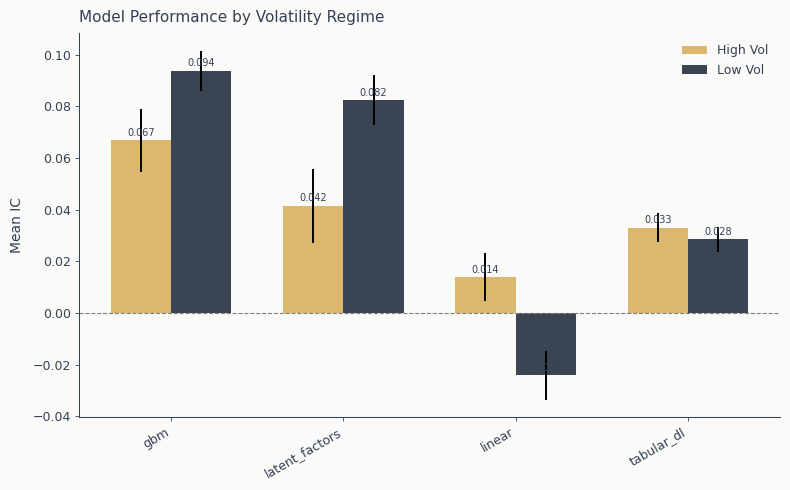

In [29]:
plot_regime_bars(regime_df)

Regime sensitivity is critical for long-short equity strategies. During
high-dispersion periods (financial crisis, COVID, sector rotations),
the cross-section separates more sharply — value stocks may collapse
while momentum stocks rally, or vice versa — creating larger spreads
for models to exploit. During low-dispersion periods, stocks move
together and cross-sectional predictability compresses.

If one model family achieves the highest IC in high-vol but fails
in low-vol, a regime-conditional strategy that switches models or
adjusts position sizing based on realized dispersion may produce a
higher net IC than a static choice.
The regime analysis also helps assess whether the overall IC estimates
are driven by a few crisis periods or persist across calm markets.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks rather than
being force-ranked against direct prediction models.

### Latent Factors (Ch14)

Four latent-factor estimators were trained on the US Firm
Characteristics panel (N~2,350, 63 characteristics): SAE, SDF, IPCA,
and CAE. PCA was not run for this case study — the LF expensive-model
policy allocates a single linear-LF slot per panel, with us_firm
routed to IPCA. SAE is the highest-IC estimator at daily-pooled
IC $\approx +0.062$, HAC CI excluding zero ($t_{HAC} \approx 5.8$).
The remaining three estimators do not separate from zero on this
panel: SDF at IC $\approx +0.009$ (CI straddles zero), IPCA at
IC $\approx -0.004$ (CI straddles zero), and CAE at
IC $\approx -0.057$ (CI excludes zero negative,
$t_{HAC} \approx -3.6$). The CAE sign-flip is structural — its
highest-IC configurations consistently produce negative IC across folds
rather than noise around zero — so on this panel the supervised
autoencoder (SAE) is the only LF estimator that contributes a
credible cross-sectional signal.

In [30]:
# Load latent factor diagnostics
lf_models = ["pca", "ipca", "cae", "sdf", "sae"]
lf_extras = {m: load_fold_extras(CASE_STUDY, m) for m in lf_models}
lf_extras = {m: e for m, e in lf_extras.items() if e is not None}

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    lf_best = (
        lf_metrics.group_by("config_name")
        .agg(ic=pl.col("ic_mean").max())
        .sort("ic", descending=True)
    )
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        print(f"  {row['config_name']:6s}: {row['ic']:+.4f}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_1m:
  sae   : +0.0620
  sdf   : +0.0143
  ipca  : -0.0039
  cae   : -0.0301

Fold extras available: ['cae', 'sdf']


#### PCA Variance Decomposition

In [31]:
if "pca" in lf_extras:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.mean(var_ratios, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(range(1, len(mean_var) + 1), mean_var, color=COLORS["blue"])
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].set_title("PCA Scree Plot (Mean Across Folds)")

    axes[1].plot(range(1, len(mean_var) + 1), np.cumsum(mean_var), marker="o", color=COLORS["blue"])
    axes[1].set_xlabel("Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].set_title(f"Top {len(mean_var)} Explain {sum(mean_var):.1%}")
    axes[1].axhline(0.5, ls="--", color="gray", alpha=0.5)
    fig.tight_layout()
    fig.show()
else:
    print("PCA was not run for this case study — IPCA covers the linear-LF slot.")

PCA was not run for this case study — IPCA covers the linear-LF slot.


PCA was not trained on this panel (LF expensive-model policy routes
us_firm to IPCA as the linear-LF representative). The IPCA loadings
below characterize the linear factor structure that PCA would have
spanned. Among the four LF estimators that were run, only the
supervised autoencoder (SAE) produces a credibly nonzero IC; the
unsupervised linear (IPCA) and unsupervised nonlinear (CAE)
estimators do not.

#### IPCA Characteristic Loadings ($\Gamma$ Matrix)

With 63 firm characteristics and ~2,350 stocks, IPCA can estimate
a rich $\Gamma$ matrix. The loadings reveal which characteristics
drive latent factor exposures.

In [32]:
if "ipca" in lf_extras:
    last_fold = lf_extras["ipca"][-1]
    if "Gamma" in last_fold:
        Gamma = np.array(last_fold["Gamma"])
        n_chars, n_factors = Gamma.shape

        # Load feature names
        feat_names = []
        for fname in ["financial.parquet", "model_based.parquet"]:
            fpath = CASE_DIR / "features" / fname
            if fpath.exists():
                cols = pl.scan_parquet(fpath).collect_schema().names()
                feat_names.extend(
                    c
                    for c in cols
                    if c not in {"symbol", "timestamp", "date", "asset"}
                    and not c.startswith("fwd_")
                )

        # Top 10 characteristics per factor
        n_top = min(10, n_chars)
        fig, axes = plt.subplots(1, min(3, n_factors), figsize=(5 * min(3, n_factors), 5))
        if min(3, n_factors) == 1:
            axes = [axes]
        for k, ax in enumerate(axes):
            col = Gamma[:, k]
            top_idx = np.argsort(np.abs(col))[-n_top:][::-1]
            labels = [feat_names[i][:25] if i < len(feat_names) else f"feat_{i}" for i in top_idx]
            vals = col[top_idx]
            colors = [COLORS["blue"] if v > 0 else COLORS["negative"] for v in vals]
            ax.barh(range(n_top), vals, color=colors)
            ax.set_yticks(range(n_top))
            ax.set_yticklabels(labels, fontsize=8)
            ax.set_title(f"Factor {k + 1}")
            ax.invert_yaxis()
        fig.suptitle("IPCA: Top Characteristics per Factor")
        fig.tight_layout()
        fig.show()

IPCA's highest daily-pooled IC on `fwd_ret_1m` is $\approx -0.004$
with a HAC CI that straddles zero ($t_{HAC} \approx -0.45$). The
$\Gamma$ loadings reveal which characteristics drive time-varying
factor exposures, but on this panel IPCA's linear mapping from
characteristics to factor loadings does not separate from zero —
it does not contribute a credible cross-sectional signal at the
raw-return horizon. (At the winsorized horizon IPCA is the
highest-IC LF estimator at IC $\approx +0.019$, but the CI still
straddles zero — see Section 6.)

#### CAE / SAE Training Convergence

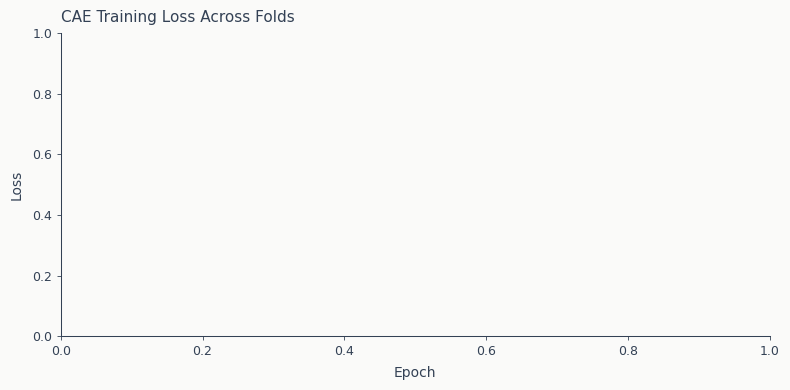

In [33]:
for model_name in ["cae", "sae"]:
    if model_name not in lf_extras:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, fold in enumerate(lf_extras[model_name]):
        losses = fold.get("epoch_losses", {})
        if losses:
            epochs = sorted(int(k) for k in losses.keys())
            vals = [losses[str(e)] for e in epochs]
            ax.plot(
                epochs,
                vals,
                alpha=0.4,
                color=COLORS["blue"],
                label=f"Fold {fold['fold_id']}" if i == 0 else None,
            )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{model_name.upper()} Training Loss Across Folds")
    ax.legend(["Individual folds"], loc="upper right")
    fig.tight_layout()
    fig.show()

SAE is the highest-IC LF estimator at daily-pooled IC $\approx +0.062$,
HAC CI excluding zero ($t_{HAC} \approx 5.8$). Its supervised
objective uses return labels during latent extraction, so the
learned factors align with the prediction target — this is what
carries SAE past the credibility boundary on the firm-characteristics
panel.

CAE behaves very differently here. Its highest daily-pooled IC is
$\approx -0.057$ with a HAC CI that excludes zero *negative*
($t_{HAC} \approx -3.6$). All ranked CAE configurations produce
similarly negative IC, so this is structural rather than fold-level
noise — the unsupervised nonlinear factor extraction inverts the
cross-sectional signal on this panel. The training-loss curves above
converge cleanly fold-to-fold (the optimization is stable), but the
converged factor space happens to score the cross-section in the
opposite direction from realized returns. The contrast with SAE on
the same panel isolates supervision as the load-bearing ingredient
for the LF family on us_firm.

#### SDF Sharpe Ratios

In [34]:
if "sdf" in lf_extras:
    sharpes = [e.get("sdf_sharpe", None) for e in lf_extras["sdf"]]
    sharpes = [s for s in sharpes if s is not None]
    if sharpes:
        print(f"SDF Sharpe across folds: mean={np.mean(sharpes):.3f}, std={np.std(sharpes):.3f}")
        print(f"  Range: [{min(sharpes):.3f}, {max(sharpes):.3f}]")

SDF Sharpe across folds: mean=1.392, std=0.281
  Range: [1.111, 1.907]


SDF's highest daily-pooled IC is $\approx +0.009$ with a HAC CI of
$[-0.002, +0.020]$ ($t_{HAC} \approx 1.6$) — directionally positive
but the CI straddles zero. The pricing-kernel objective produces
stable internal Sharpe statistics across folds (above), but the
factor structure it learns does not translate into a credibly
nonzero cross-sectional IC on this panel. Among LF estimators on
us_firm, only SAE clears the credibility boundary; SDF, IPCA, and
CAE do not.

### Causal DML (Ch15)

Causal DML lives in a dedicated `causal_runs` table in the registry:
it estimates the average treatment effect (ATE) of a treatment
variable on the outcome after orthogonalizing confounders, with
HAC-corrected standard errors. The output is an
effect size and p-value, not a cross-sectional IC, and so does not
slot into the IC + HAC-CI panel above.

In [ ]:
# Load causal_dml evidence from the dedicated causal_runs table.
import sqlite3

_causal_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_causal_db)) as _conn:
    _conn.row_factory = sqlite3.Row
    _causal_rows = [
        dict(r)
        for r in _conn.execute(
            "SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac, "
            "       naive_effect, confounding_bias_pct, refutation_p, n_folds, n_obs "
            "FROM causal_runs ORDER BY label"
        ).fetchall()
    ]

if _causal_rows:
    causal_df = pl.DataFrame(_causal_rows)
    print("Causal DML — ATE of treatment on outcome (orthogonalized for confounders):")
    print(
        causal_df.select(
            "label",
            "treatment",
            pl.col("dml_effect").round(5).alias("ate"),
            pl.col("dml_se_hac").round(5).alias("se_hac"),
            pl.col("p_value_hac").round(4).alias("p_hac"),
            pl.col("naive_effect").round(5).alias("naive"),
            pl.col("confounding_bias_pct").round(1).alias("bias_pct"),
            pl.col("refutation_p").round(2).alias("ref_p"),
            pl.col("n_folds").cast(pl.Int64).alias("folds"),
            pl.col("n_obs").cast(pl.Int64).alias("n"),
        )
    )
else:
    print("No causal_runs rows for this case study")

The accepted specification uses `r12_2` momentum as the treatment and
{Beta, IdioVol, LME, Variance} as confounders. Five expanding folds keep
complete decision months together and apply a one-month embargo. On the
31,408-row out-of-fold comparison sample, the naive estimate is
$+0.02782$ and the orthogonalized estimate is $+0.02266$. Driscoll-Kraay
inference gives SE $0.01473$ and two-sided $p=0.1481$; the entity-aware
placebo test gives empirical $p=1.0$.

The point estimate is positive, but it clears neither inferential gate.
The corrected evidence therefore does not support a nonzero causal
momentum effect after conditioning on the observed characteristics.
This is *not* an IC claim: GBM remains the validation-selected predictive
input for backtesting, while the DML result is a separate conditional
causal diagnostic with a null publication conclusion.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling — the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [36]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""gbm""","""leaves_15_mae""",0.8,0.767607,1.707274,254883
"""gbm""","""leaves_15_mae""",0.9,0.878576,2.500804,254883
"""gbm""","""leaves_15_mae""",0.95,0.937312,3.406096,254883
"""latent_factors""","""sae""",0.8,0.755866,1.714064,229362
"""latent_factors""","""sae""",0.9,0.875803,2.522239,229362
…,…,…,…,…,…
"""linear""","""ridge_a0.001""",0.9,0.88049,2.558525,254883
"""linear""","""ridge_a0.001""",0.95,0.938776,3.475591,254883
"""tabular_dl""","""tabm_s""",0.8,0.768976,1.751511,254883


In [37]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (4, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ gbm        ┆ leaves_15_ ┆ 0.767607   ┆ 0.878576  ┆ 0.937312  ┆ 1.707274  ┆ 2.500804  ┆ 3.406096  │
│      

Empirical coverage tracks the nominal levels closely across all four
families. The largest deviation is at the 80% level, where every
family under-covers by 3.0–4.4pp — empirical coverage falls in the
0.756–0.770 range against a 0.80 target, with SAE the worst-calibrated
at 0.756. The gap shrinks at higher nominal levels: at 90% the
maximum deviation is $\approx$1.4pp (SAE at 0.876), and at 95% it is
$\approx$1.4pp (SAE at 0.936). The 80%-level under-coverage is
consistent with monthly equity returns having heavier-than-Gaussian
tails that the fold-0 residual quantile under-states near the centre
of the distribution; the residual distribution is closer to symmetric
far in the tails, so the 95% quantile lands within $\sim$1.4pp of
nominal across families.

Width-per-std is the more useful axis for distinguishing models at
matched coverage. The highest-IC GBM config (`leaves_15_mae`) produces
the tightest intervals at every nominal level
($\approx 1.71$ × std at 80%, $\approx 2.50$ at 90%, $\approx 3.41$
at 95%), with SAE next at $\approx 1.71/2.52/3.44$ × std. Ridge
($\alpha=0.001$) and TabM-S sit wider, with TabM-S the widest at
every level ($\approx 1.75/2.58/3.52$ × std). At 95% coverage the
tightest family produces intervals about 3% narrower per std than
the widest — small in absolute terms but consistent across levels,
and a meaningful input when intervals feed Ch19 volatility-targeted
position sizing.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations. Not every
model that was trained deserves a backtest — advancing fragile models
wastes compute and risks false confidence from overfitting the
backtest configuration.

In [38]:
synthesis_rows = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean"]
    ic_std_val = row.get("ic_std") or 0

    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )

    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        median_ic = float(np.median(fold_ics))
        std_ic = float(np.std(fold_ics))
        pct_pos = float((fold_ics > 0).mean())
        worst = float(np.min(fold_ics))
    else:
        median_ic, std_ic, pct_pos, worst = (
            ic_mean,
            ic_std_val,
            (1.0 if ic_mean > 0 else 0.0),
            ic_mean,
        )

    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )

    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        recommendation = "Backtest"
    elif ic_mean > 0:
        recommendation = "Backtest (marginal)"
    else:
        recommendation = "Exclude"

    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 0),
            "recommendation": recommendation,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (4, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ recommend │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ation     │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str       │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ gbm        ┆ leaves_15 ┆ 0.0803  ┆ 0.0748    ┆ … ┆ 1.0       ┆ 0.007     ┆ 170.0     ┆ Backtest  │
│            ┆ _mae      ┆         ┆           ┆   ┆           ┆           ┆           ┆           │
│ latent_fac ┆ sae       ┆ 0.062   ┆ 0.0671    ┆ … ┆ 1.0       ┆ 0.0028    ┆ 30.0      ┆ Backtest  │
│ tors       ┆           ┆         ┆           ┆   ┆        

### What the empirical record says

**Two families separate from zero strongly on raw returns.** GBM
(`leaves_15_mae`) at IC $\approx +0.080$ ($t_{HAC} \approx 8.1$) and
SAE at IC $\approx +0.062$ ($t_{HAC} \approx 5.8$) both have HAC
95% CIs that clearly exclude zero with margin. Tabular DL (TabM-S)
at IC $\approx +0.031$ ($t_{HAC} \approx 7.3$) is also credibly
nonzero but materially below the leading pair.

**One family is below credibility.** Linear (ridge $\alpha=0.001$)
at IC $\approx -0.005$ has a CI that straddles zero on the raw-return
label. Section 6 shows that label transformation (winsorization,
classification) restores credibility for the linear family — but on
the raw-returns target it does not contribute a reliable standalone
signal.

**Latent-factor estimators differentiate sharply.** Only SAE clears
the credibility boundary. SDF (CI straddles zero), IPCA (CI
straddles zero), and CAE (CI excludes zero *negative*) do not.
Supervision is the load-bearing ingredient on this panel — the only
LF estimator that uses return labels during latent extraction is
also the only LF estimator that produces a credible signal.

### Forecast representation downstream

For backtesting, predictions are used as:

- **Decile sorting**: rank by `y_score`, go long top decile, short
  bottom decile — the classic long-short factor portfolio
- **Score weighting**: use `y_score` magnitudes for position sizing
  within deciles
- **Ensemble**: pairwise correlation $< 0.7$ is the threshold for
  ensembling, applied in Ch20 across families that survive the
  signal-stage backtest. The relevant ensemble candidates here are
  GBM, SAE, and TabM-S — the three families with credibly nonzero
  IC on the primary label.

### What this analysis does NOT tell us

- **Transaction costs at scale**: GBM's decile spread must survive
  round-trip costs of 10--40 bps (2x per-leg cost) plus borrow costs for
  the short leg. With monthly rebalancing and ~2,500 stocks, turnover
  and market impact could be substantial.
- **Capacity**: small-cap names in the bottom decile may be illiquid.
  A realistic long-short portfolio may need to exclude micro-caps or
  cap position sizes.
- **Survivorship bias**: the universe applies standard academic filters
  (price > \$5, volume > \$1M) but does not perfectly replicate
  point-in-time index membership. Actual returns to a live strategy
  may be lower.
- **Short-sale constraints**: not all bottom-decile stocks are borrowable
  at reasonable rates. The long-short spread overstates the achievable
  edge if borrow costs are high.

**Next**: `11_backtest.py` for strategy simulation,
[`12_portfolio_management`](12_portfolio_management.ipynb) for position sizing, and
`15_strategy_analysis.py` for end-to-end results.

## Key Takeaways

1. **GBM and SAE separate from zero strongly on raw returns**: GBM
   (`leaves_15_mae`) at IC $\approx +0.080$ ($t_{HAC} \approx 8.1$)
   and SAE at IC $\approx +0.062$ ($t_{HAC} \approx 5.8$) both have
   HAC 95% CIs that clearly exclude zero. These are the two families
   that contribute a credible standalone cross-sectional signal on
   the firm-characteristics panel.
2. **Latent-factor results split sharply by supervision**: SAE clears
   credibility (IC $\approx +0.062$, CI excludes zero); SDF (CI
   straddles zero), IPCA (CI straddles zero), and CAE (CI excludes
   zero *negative*) do not. The LF estimator that uses return labels
   during latent extraction is also the only one that produces a
   credible signal — supervision is the load-bearing ingredient on
   this panel. PCA was not run for this case study.
3. **Tabular DL is credibly nonzero, materially below the leaders**:
   TabM-S at IC $\approx +0.031$ ($t_{HAC} \approx 7.3$) has a CI
   that excludes zero but is well below GBM and SAE in magnitude.
   A useful ensemble diversifier rather than a standalone candidate.
4. **Label design moves the linear family across credibility**:
   ridge $\alpha=0.001$ on raw returns sits at IC $\approx -0.005$
   (CI straddles zero), but a winsorized-label ridge $\alpha=10^5$
   reaches IC $\approx +0.023$ (CI excludes zero with thin margin).
   For nonlinear families like GBM the label transformation has
   little effect — the MAE loss already absorbs the tail-return
   mass that winsorization removes.
5. **Conformal coverage is well calibrated near nominal**: empirical
   coverage tracks the 80/90/95% targets within $\sim$3pp at the 80%
   level (universal under-coverage from heavier-than-Gaussian tails)
   and within $\sim$1.3pp at 95%. GBM and SAE produce the tightest
   intervals per std of returns at matched coverage.
6. **Causal DML is not on the IC axis**: the orthogonalized estimate
   is $+0.02266$ with Driscoll-Kraay $p=0.1481$ and entity-aware
   placebo $p=1.0$. The positive point estimate clears neither gate,
   so the corrected causal conclusion is null. This conditional
   effect estimate remains separate from the predictive-family IC
   ranking and does not alter the GBM input selected for backtesting.

**Next**: `11_backtest.py` applies these predictions to simulated trading.